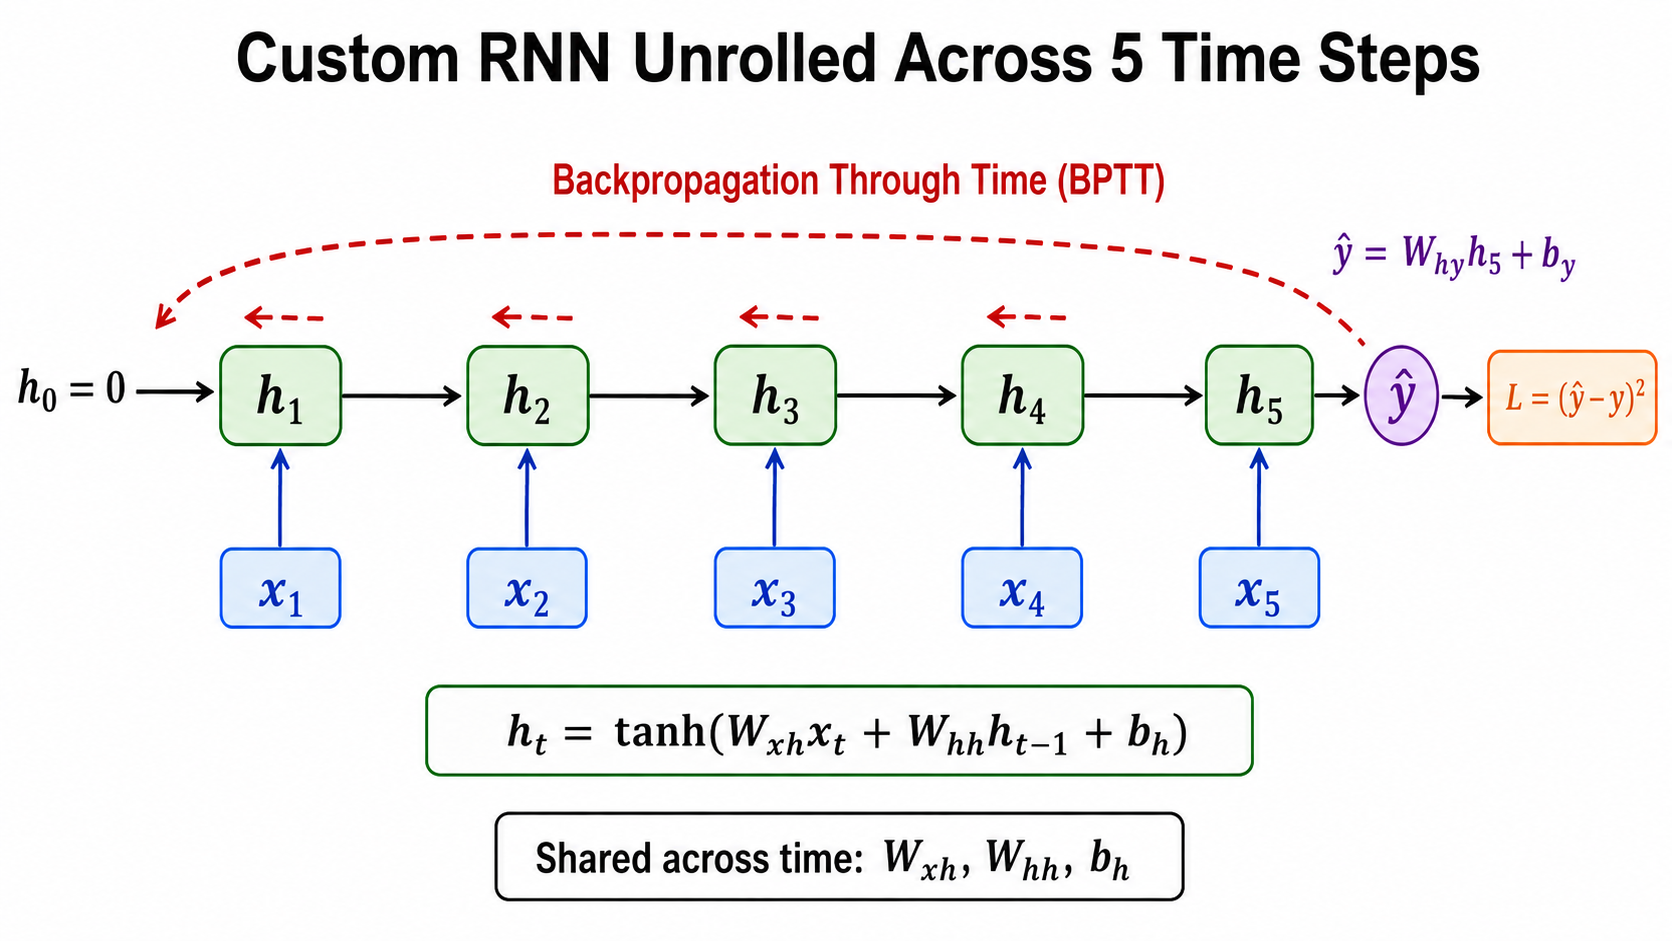

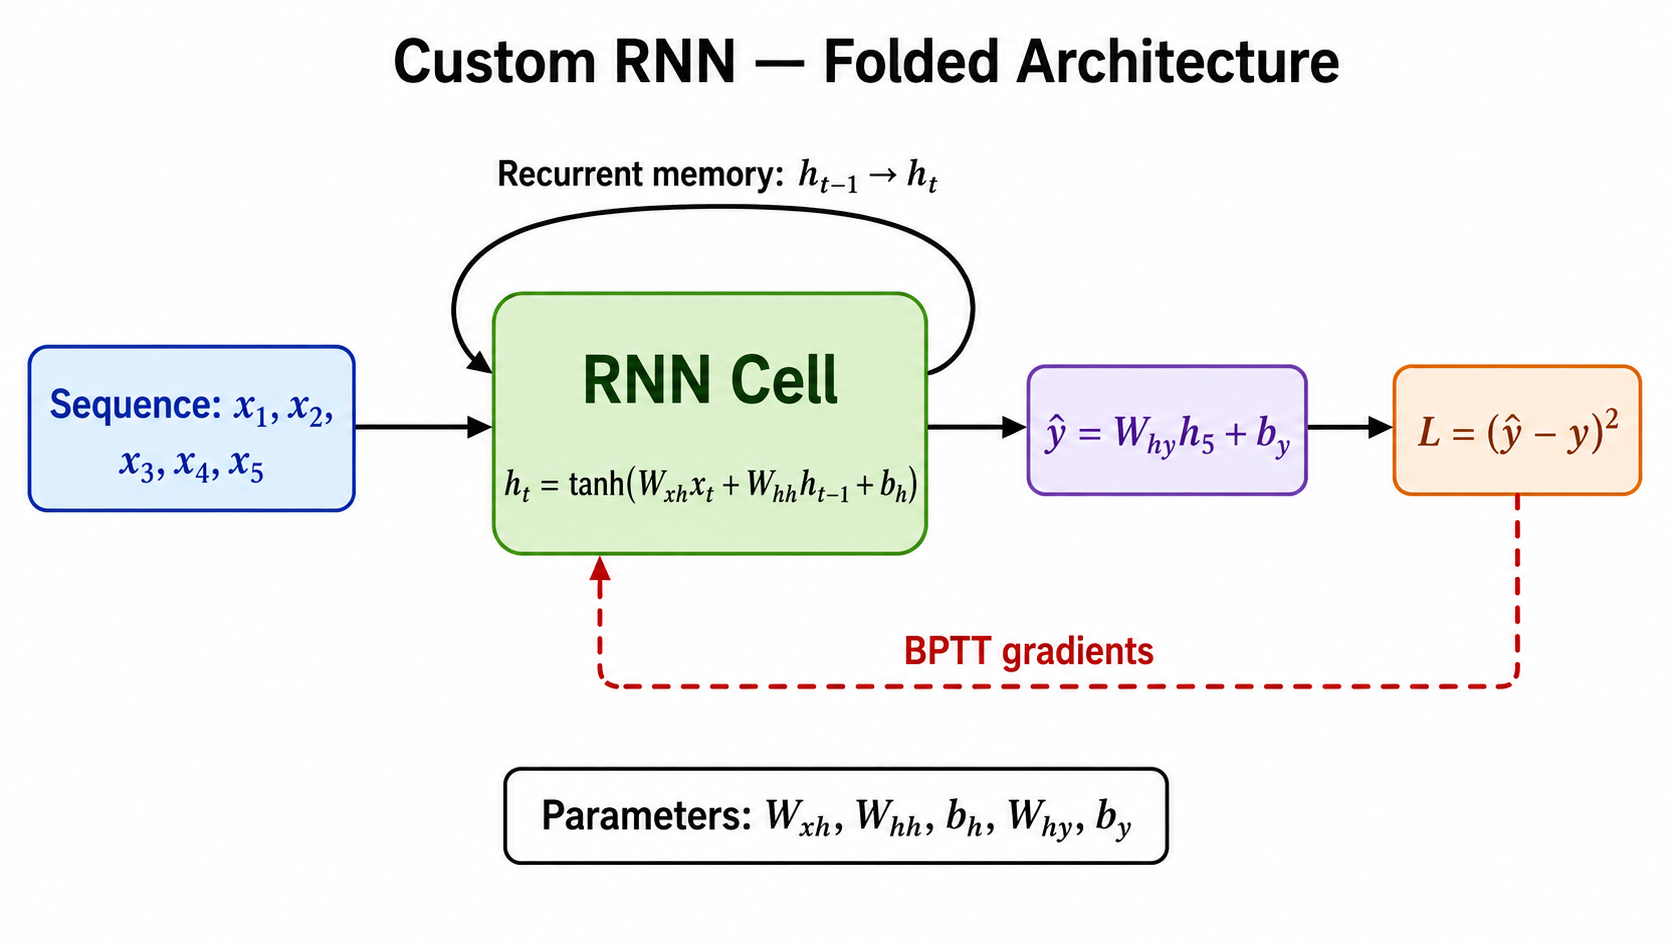

In [2]:
import torch
import torch.nn as nn


In [3]:
torch.manual_seed(42)

In [22]:
torch.randn(1, 5)

tensor([[-0.6430,  0.7113,  0.4000, -1.2039, -0.4198]])

In [24]:
nn.Parameter(torch.randn(1, 5))

Parameter containing:
tensor([[-1.1929,  0.6056,  0.2442,  0.3988,  1.7937]], requires_grad=True)

In [25]:
nn.Parameter(torch.tensor(1.))

Parameter containing:
tensor(1., requires_grad=True)

In [7]:
class CustomRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # Input-to-hidden parameters
        self.W_xh = nn.Parameter(torch.randn(hidden_size, input_size) * 0.1)

        # Hidden-to-hidden recurrent parameters
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.1)

        self.b_h = nn.Parameter(torch.zeros(hidden_size))

        # Hidden-to-output parameters
        self.W_hy = nn.Parameter(torch.randn(output_size, hidden_size) * 0.1)

        self.b_y = nn.Parameter(torch.zeros(output_size))

    def forward(self, x):
        """
        x shape: (batch_size, sequence_length, input_size)
        """

        batch_size, sequence_length, _ = x.shape

        # Initial memory/hidden state
        h = torch.zeros(batch_size,self.W_hh.shape[0],device=x.device)

        hidden_states = []

        # Process one time step at a time
        for t in range(sequence_length):
            x_t = x[:, t, :]

            # Recurrent neuron computation
            h = torch.tanh(x_t @ self.W_xh.T + h @ self.W_hh.T + self.b_h)

            hidden_states.append(h)

        # Use the final hidden state for prediction
        output = h @ self.W_hy.T + self.b_y

        return output, hidden_states

In [8]:
# 1. Create a sequence with T = 5 time steps
batch_size = 1
sequence_length = 5
input_size = 2
hidden_size = 3
output_size = 1

x = torch.tensor(
    [
        [
            [1.0, 0.5],   # t = 1
            [0.2, 0.1],   # t = 2
            [0.4, 0.7],   # t = 3
            [0.8, 0.3],   # t = 4
            [0.6, 0.9],   # t = 5
        ]
    ]
)

target = torch.tensor([[1.0]])

In [27]:
x.shape

torch.Size([1, 5, 2])

In [29]:
x[:, 2,:]

tensor([[0.4000, 0.7000]])

In [9]:
# 2. Forward pass
model = CustomRNN(input_size=input_size, hidden_size=hidden_size,output_size=output_size)

prediction, hidden_states = model(x)

# Scalar mean-squared-error loss
loss = torch.mean((prediction - target) ** 2)

print("Prediction:", prediction)
print("Target:", target)
print("Scalar loss:", loss.item())

Prediction: tensor([[0.0009]], grad_fn=<AddBackward0>)
Target: tensor([[1.]])
Scalar loss: 0.9981640577316284


In [10]:
# 3. Backward pass
model.zero_grad()
loss.backward()


In [12]:
# 4. Print every parameter and its gradient
for name, parameter in model.named_parameters():
    print(f"\nParameter: {name}")
    print("Parameter value:")
    print(parameter.data)

    print("Gradient:")
    print(parameter.grad)

    print("Gradient shape:", parameter.grad.shape)


Parameter: W_xh
Parameter value:
tensor([[ 0.0337,  0.0129],
        [ 0.0234,  0.0230],
        [-0.1123, -0.0186]])
Gradient:
tensor([[-0.1761, -0.2039],
        [-0.1342, -0.2240],
        [-0.1085, -0.1501]])
Gradient shape: torch.Size([3, 2])

Parameter: W_hh
Parameter value:
tensor([[ 0.2208, -0.0638,  0.0462],
        [ 0.0267,  0.0535,  0.0809],
        [ 0.1110, -0.1690, -0.0989]])
Gradient:
tensor([[-0.0080, -0.0062,  0.0218],
        [-0.0077, -0.0054,  0.0224],
        [-0.0055, -0.0041,  0.0156]])
Gradient shape: torch.Size([3, 3])

Parameter: b_h
Parameter value:
tensor([0., 0., 0.])
Gradient:
tensor([-0.2781, -0.2288, -0.1762])
Gradient shape: torch.Size([3])

Parameter: W_hy
Parameter value:
tensor([[0.0958, 0.1322, 0.0817]])
Gradient:
tensor([[-0.0662, -0.0589,  0.1505]])
Gradient shape: torch.Size([1, 3])

Parameter: b_y
Parameter value:
tensor([0.])
Gradient:
tensor([-1.9982])
Gradient shape: torch.Size([1])
